In [1]:
import pandas as pd 
import numpy as np
import sklearn as sk
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.DataFrame(pd.read_csv(r'C:\Users\MSI\Desktop\Heart Disease\Data\data.csv'))

In [3]:
# Convert column to string and strip extra spaces so that we encode them
df["Heart Disease"] = df["Heart Disease"].astype(str).str.strip()
# Remove leading/trailing spaces and standardize
df["Heart Disease"] = df["Heart Disease"].map({"Absence": 0, "Presence": 1})
df.head()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,1
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,0
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,0
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,0
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,1


In [10]:
#we are going to drop around 7K samples with label 0 in order to balance the dataset .
rows_with_0 = df[df["Heart Disease"] == 0]
rows_to_drop = rows_with_0.sample(9000, random_state=42)  # random 7000
df = df.drop(rows_to_drop.index)
df["Heart Disease"].value_counts()

Heart Disease
0    288546
1    282454
Name: count, dtype: int64

In [12]:
# Define features and target variable ,we'll use only numerical features for simplicity and the most correlated ones with our target variable
numerical_features = ["Number of vessels fluro", "ST depression", "Age", "Cholesterol", "BP", "Max HR","Thallium"]
X = df[numerical_features]
y = df["Heart Disease"]

In [13]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=42, stratify=y)

In [14]:
print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Training samples: 456800
Testing samples: 114200


In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)


Test Accuracy: 0.8474


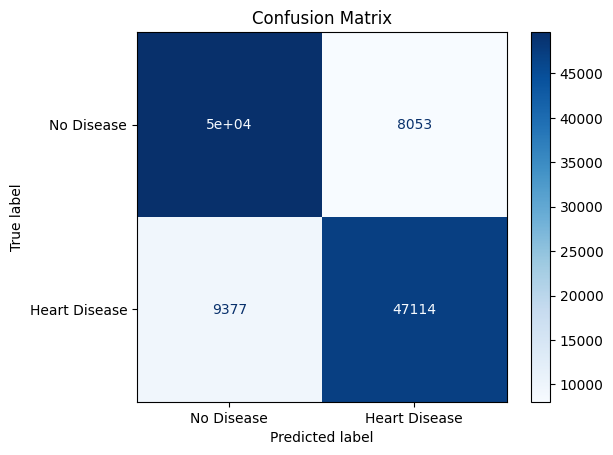

Classification Report:
               precision    recall  f1-score   support

   No Disease       0.84      0.86      0.85     57709
Heart Disease       0.85      0.83      0.84     56491

     accuracy                           0.85    114200
    macro avg       0.85      0.85      0.85    114200
 weighted avg       0.85      0.85      0.85    114200



In [17]:
from sklearn.linear_model import LogisticRegression

# Logistic Regression with balanced class weights
model = LogisticRegression(random_state=42, class_weight="balanced")
model.fit(X_train_scaled, y_train)

# Predict
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:,1]

# 6️⃣ Evaluate Accuracy
acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {acc:.4f}")

# 7️⃣ Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Disease", "Heart Disease"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

# 8️⃣ Classification Report (Precision, Recall, F1)
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["No Disease", "Heart Disease"]))




In [20]:
# 1️⃣ Select features
numerical_features = ["Number of vessels fluro", "ST depression", "Age", "Cholesterol", "BP", "Max HR","Thallium"]
categorical_features = ["Sex", "Chest pain type", "Exercise angina", "Slope of ST"]

# One-hot encode categorical features
X_cat = pd.get_dummies(df[categorical_features], drop_first=True)

# Combine numerical + categorical features
X = pd.concat([df[numerical_features], X_cat], axis=1)
y = df["Heart Disease"]
# -----------------------------
# 2️⃣ Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# -----------------------------
# 3️⃣ Scale numerical features
scaler = StandardScaler()
X_train[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_test[numerical_features] = scaler.transform(X_test[numerical_features])



Test Accuracy: 0.8474


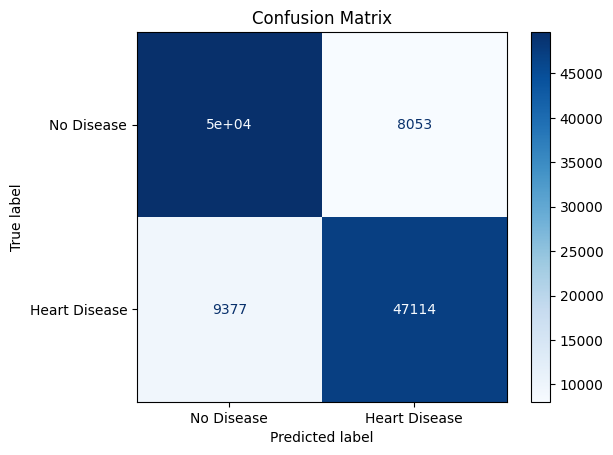

Classification Report:
               precision    recall  f1-score   support

   No Disease       0.84      0.86      0.85     57709
Heart Disease       0.85      0.83      0.84     56491

     accuracy                           0.85    114200
    macro avg       0.85      0.85      0.85    114200
 weighted avg       0.85      0.85      0.85    114200



In [22]:
from sklearn.linear_model import LogisticRegression

# Logistic Regression with balanced class weights
model = LogisticRegression(random_state=42, class_weight="balanced")
model.fit(X_train_scaled, y_train)

# Predict
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:,1]

# 6️⃣ Evaluate Accuracy
acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {acc:.4f}")

# 7️⃣ Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Disease", "Heart Disease"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

# 8️⃣ Classification Report (Precision, Recall, F1)
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["No Disease", "Heart Disease"]))




In [23]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
from sklearn.metrics import accuracy_score, classification_report
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=["No Disease", "Heart Disease"]))

Accuracy: 0.8773555166374781
               precision    recall  f1-score   support

   No Disease       0.88      0.88      0.88     57709
Heart Disease       0.88      0.87      0.88     56491

     accuracy                           0.88    114200
    macro avg       0.88      0.88      0.88    114200
 weighted avg       0.88      0.88      0.88    114200



c:\Users\MSI\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:200: UserWarning: [14:41:30] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Test Accuracy: 0.8869

Classification Report:
               precision    recall  f1-score   support

   No Disease       0.89      0.89      0.89     57709
Heart Disease       0.89      0.88      0.89     56491

     accuracy                           0.89    114200
    macro avg       0.89      0.89      0.89    114200
 weighted avg       0.89      0.89      0.89    114200



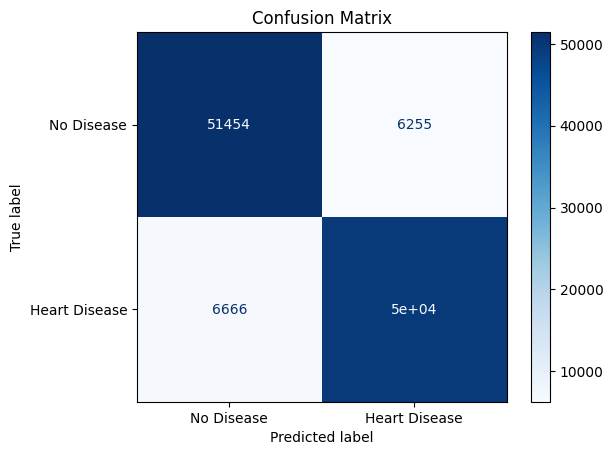


Top Features:
                    Feature  Importance
6                  Thallium    0.571561
8           Chest pain type    0.133475
9           Exercise angina    0.089636
0   Number of vessels fluro    0.064035
10              Slope of ST    0.057878
7                       Sex    0.045665
1             ST depression    0.017334
5                    Max HR    0.013721
2                       Age    0.004587
3               Cholesterol    0.001282


In [19]:
from xgboost import XGBClassifier

# -----------------------------
# 1️⃣ Select features
numerical_features = ["Number of vessels fluro", "ST depression", "Age", "Cholesterol", "BP", "Max HR","Thallium"]
categorical_features = ["Sex", "Chest pain type", "Exercise angina", "Slope of ST"]

# One-hot encode categorical features
X_cat = pd.get_dummies(df[categorical_features], drop_first=True)

# Combine numerical + categorical features
X = pd.concat([df[numerical_features], X_cat], axis=1)
y = df["Heart Disease"]

# -----------------------------
# 2️⃣ Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# -----------------------------
# 3️⃣ Scale numerical features
scaler = StandardScaler()
X_train[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_test[numerical_features] = scaler.transform(X_test[numerical_features])

# -----------------------------
# 4️⃣ Train XGBoost
xgb_model = XGBClassifier(
    n_estimators=350,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    eval_metric="logloss",
    use_label_encoder=False
)
xgb_model.fit(X_train, y_train)

# -----------------------------
# 5️⃣ Predictions
y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)[:,1]

# -----------------------------
# 6️⃣ Evaluate
acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {acc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["No Disease", "Heart Disease"]))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Disease", "Heart Disease"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

# -----------------------------
# 7️⃣ Feature Importance
importances = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nTop Features:")
print(importances.head(10))

Fitting 5 folds for each of 50 candidates, totalling 250 fits


c:\Users\MSI\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:200: UserWarning: [13:36:19] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best Parameters: {'subsample': 0.6, 'reg_lambda': 2, 'reg_alpha': 0, 'n_estimators': 500, 'max_depth': 4, 'learning_rate': 0.1, 'gamma': 0.4, 'colsample_bytree': 0.9}
Test Accuracy: 0.8870

Classification Report:
               precision    recall  f1-score   support

   No Disease       0.89      0.89      0.89     57909
Heart Disease       0.89      0.88      0.89     56491

     accuracy                           0.89    114400
    macro avg       0.89      0.89      0.89    114400
 weighted avg       0.89      0.89      0.89    114400



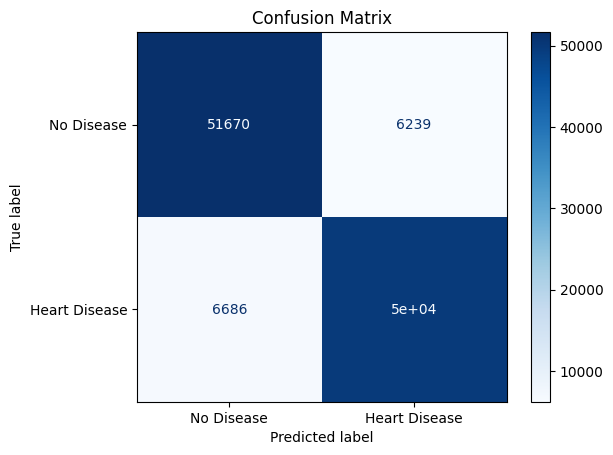


Top Features:
                    Feature  Importance
10                 Thallium    0.525024
7           Chest pain type    0.143027
8           Exercise angina    0.115255
0   Number of vessels fluro    0.065375
9               Slope of ST    0.061320
6                       Sex    0.046963
1             ST depression    0.019511
5                    Max HR    0.014767
2                       Age    0.005943
3               Cholesterol    0.001657


In [60]:
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from xgboost import XGBClassifier
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1️⃣ Features
numerical_features = ["Number of vessels fluro", "ST depression", "Age", "Cholesterol", "BP", "Max HR"]
categorical_features = ["Sex", "Chest pain type", "Exercise angina", "Slope of ST", "Thallium"]

# One-hot encode categorical features
X_cat = pd.get_dummies(df[categorical_features], drop_first=True)

# Combine numerical + categorical features
X = pd.concat([df[numerical_features], X_cat], axis=1)
y = df["Heart Disease"]

# -----------------------------
# 2️⃣ Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# -----------------------------
# 3️⃣ Scale numerical features
scaler = StandardScaler()
X_train[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_test[numerical_features] = scaler.transform(X_test[numerical_features])

# -----------------------------
# 4️⃣ XGBoost hyperparameter tuning using RandomizedSearchCV

xgb = XGBClassifier(
    random_state=42,
    use_label_encoder=False,
    eval_metric="logloss"
)

# Define the hyperparameter grid
param_dist = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [3, 4, 5, 6, 7],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'gamma': [0, 0.1, 0.2, 0.3, 0.4],
    'reg_alpha': [0, 0.01, 0.1, 1],
    'reg_lambda': [1, 1.5, 2, 3]
}

# Randomized Search
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=50,           # number of random combinations
    scoring='accuracy',
    cv=5,                # 5-fold cross-validation
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

# Best parameters
print("Best Parameters:", random_search.best_params_)
best_xgb = random_search.best_estimator_

# -----------------------------
# 5️⃣ Predictions & Evaluation
y_pred = best_xgb.predict(X_test)
y_prob = best_xgb.predict_proba(X_test)[:,1]

acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {acc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["No Disease", "Heart Disease"]))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Disease", "Heart Disease"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

# -----------------------------
# 6️⃣ Feature Importance
importances = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_xgb.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nTop Features:")
print(importances.head(10))

Best Hyperparameters: {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
Mean CV Accuracy: 0.7962


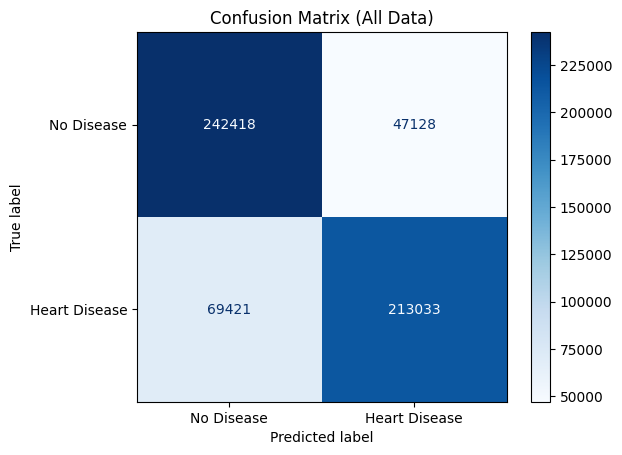

Classification Report:
               precision    recall  f1-score   support

   No Disease       0.78      0.84      0.81    289546
Heart Disease       0.82      0.75      0.79    282454

     accuracy                           0.80    572000
    macro avg       0.80      0.80      0.80    572000
 weighted avg       0.80      0.80      0.80    572000



C:\Users\MSI\AppData\Local\Temp\ipykernel_13760\195113020.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Coefficient", y="Feature", data=feature_importance, palette="viridis")


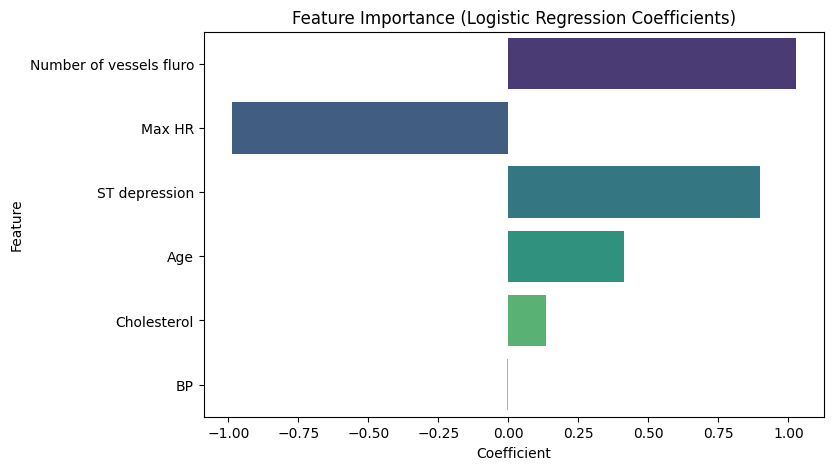

In [43]:
import pandas as pd
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

# 1️⃣ Features and target
numerical_features = ["Number of vessels fluro", "ST depression", "Age", "Cholesterol", "BP", "Max HR"]
X = df[numerical_features]
y = df["Heart Disease"]

# 2️⃣ Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3️⃣ Define Logistic Regression and parameter grid
logreg = LogisticRegression(random_state=42, max_iter=1000)
param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],   # Regularization strength
    "penalty": ["l2"],               # L2 regularization (default)
    "solver": ["lbfgs"]
}

# 4️⃣ Stratified K-Fold
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 5️⃣ GridSearchCV with cross-validation
grid = GridSearchCV(
    estimator=logreg,
    param_grid=param_grid,
    cv=kf,
    scoring="accuracy",
    n_jobs=-1
)
grid.fit(X_scaled, y)

# 6️⃣ Best hyperparameters and score
print("Best Hyperparameters:", grid.best_params_)
print(f"Mean CV Accuracy: {grid.best_score_:.4f}")

# 7️⃣ Evaluate on the same data (or split if you want separate test set)
best_model = grid.best_estimator_
y_pred = best_model.predict(X_scaled)

# Confusion Matrix
cm = confusion_matrix(y, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Disease", "Heart Disease"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix (All Data)")
plt.show()

# Classification Report
print("Classification Report:")
print(classification_report(y, y_pred, target_names=["No Disease", "Heart Disease"]))

# Feature Importance
feature_importance = pd.DataFrame({
    "Feature": numerical_features,
    "Coefficient": best_model.coef_[0]
}).sort_values(by="Coefficient", key=abs, ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x="Coefficient", y="Feature", data=feature_importance, palette="viridis")
plt.title("Feature Importance (Logistic Regression Coefficients)")
plt.show()

5-Fold CV Accuracy Scores: [0.79805556 0.79930556 0.80077381 0.79763889 0.80113095]
Mean CV Accuracy: 0.7994

Test Accuracy: 0.8015


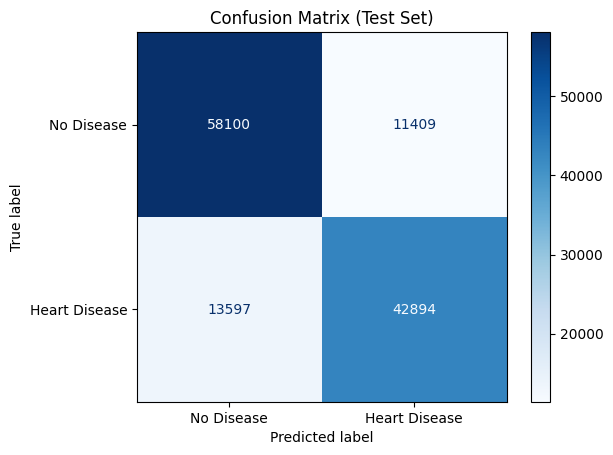


Classification Report (Test Set):
               precision    recall  f1-score   support

   No Disease       0.81      0.84      0.82     69509
Heart Disease       0.79      0.76      0.77     56491

     accuracy                           0.80    126000
    macro avg       0.80      0.80      0.80    126000
 weighted avg       0.80      0.80      0.80    126000



C:\Users\MSI\AppData\Local\Temp\ipykernel_19400\3658825381.py:86: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Coefficient", y="Feature", data=feature_importance, palette="viridis")


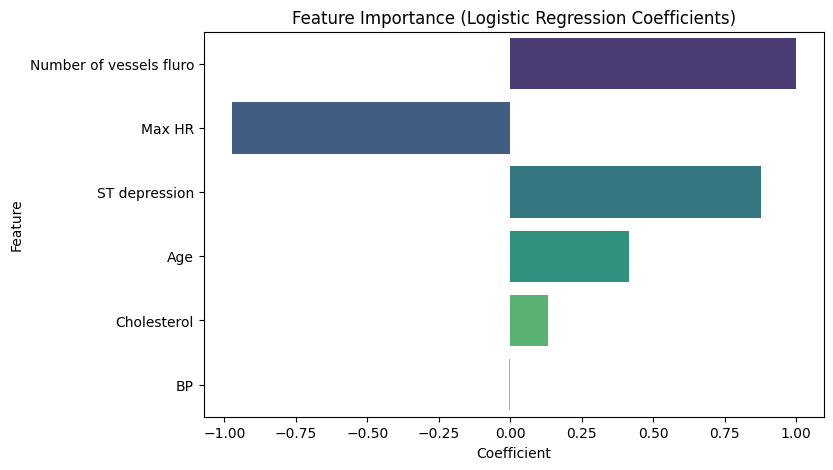

In [20]:
# -----------------------------
# Logistic Regression with class_weight="balanced" + k-fold CV
# -----------------------------
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# -----------------------------
# 1️⃣ Features and target
# -----------------------------
numerical_features = ["Number of vessels fluro", "ST depression", "Age", "Cholesterol", "BP", "Max HR"]
X = df[numerical_features]
y = df["Heart Disease"]

# -----------------------------
# 2️⃣ Split into train/test
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# -----------------------------
# 3️⃣ Standardize features
# -----------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# -----------------------------
# 4️⃣ Define Logistic Regression with class_weight balanced
# -----------------------------
model = LogisticRegression(random_state=42, class_weight="balanced", max_iter=1000)

# -----------------------------
# 5️⃣ Stratified K-Fold Cross-Validation
# -----------------------------
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=kf, scoring="accuracy")

print(f"5-Fold CV Accuracy Scores: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean():.4f}")

# -----------------------------
# 6️⃣ Train on full training set
# -----------------------------
model.fit(X_train_scaled, y_train)

# -----------------------------
# 7️⃣ Evaluate on test set
# -----------------------------
y_pred = model.predict(X_test_scaled)

# Accuracy
test_acc = accuracy_score(y_test, y_pred)
print(f"\nTest Accuracy: {test_acc:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Disease", "Heart Disease"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix (Test Set)")
plt.show()

# Classification Report
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_pred, target_names=["No Disease", "Heart Disease"]))

# -----------------------------
# 8️⃣ Feature Importance (Coefficients)
# -----------------------------
feature_importance = pd.DataFrame({
    "Feature": numerical_features,
    "Coefficient": model.coef_[0]
}).sort_values(by="Coefficient", key=abs, ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x="Coefficient", y="Feature", data=feature_importance, palette="viridis")
plt.title("Feature Importance (Logistic Regression Coefficients)")
plt.show()

In [ ]:
# -----------------------------
# SVM Classifier with class_weight balanced + k-fold CV
# -----------------------------
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

# 1️⃣ Features and target
numerical_features = ["Number of vessels fluro", "ST depression", "Age", "Cholesterol", "BP", "Max HR"]
X = df[numerical_features]
y = df["Heart Disease"]

# 2️⃣ Split into train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3️⃣ Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4️⃣ Define SVM classifier with class_weight balanced
svm_model = SVC(kernel="rbf", class_weight="balanced", probability=True, random_state=42)

# 5️⃣ Stratified K-Fold Cross-Validation
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(svm_model, X_train_scaled, y_train, cv=kf, scoring="accuracy")

print(f"5-Fold CV Accuracy Scores: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean():.4f}")

# 6️⃣ Train on full training set
svm_model.fit(X_train_scaled, y_train)

# 7️⃣ Evaluate on test set
y_pred = svm_model.predict(X_test_scaled)

# Accuracy
test_acc = accuracy_score(y_test, y_pred)
print(f"\nTest Accuracy: {test_acc:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Disease", "Heart Disease"])
disp.plot(cmap="Blues")
plt.title("SVM Confusion Matrix (Test Set)")
plt.show()

# Classification Report
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_pred, target_names=["No Disease", "Heart Disease"]))

In [1]:
# -----------------------------
# SVM Classifier (single train/test split)
# -----------------------------
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay



In [11]:
# 1️⃣ Features and target
numerical_features = ["Number of vessels fluro", "ST depression", "Age", "Cholesterol", "BP", "Max HR"]
X = df[numerical_features]
y = df["Heart Disease"]

# 2️⃣ Split into train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3️⃣ Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")
print(f"Class distribution in training set:\n{y_train.value_counts()}")


Training samples: 504000
Testing samples: 126000
Class distribution in training set:
Heart Disease
0    278037
1    225963
Name: count, dtype: int64


In [ ]:
# 4️⃣ Define SVM classifier with class_weight balanced
svm_model = SVC(kernel="rbf", class_weight="balanced", probability=True, random_state=42)

# 5️⃣ Train SVM on training set
svm_model.fit(X_train_scaled, y_train)

# 6️⃣ Predict on test set
y_pred = svm_model.predict(X_test_scaled)

# 7️⃣ Evaluate
test_acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {test_acc:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Disease", "Heart Disease"])
disp.plot(cmap="Blues")
plt.title("SVM Confusion Matrix (Test Set)")
plt.show()

# Classification Report
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_pred, target_names=["No Disease", "Heart Disease"]))

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:   45.6s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:  2.9min
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:  3.1min finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    1.3s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    7.8s
[Parallel(n_jobs=12)]: Done 200 out of 200 | elapsed:    8.9s finished


Random Forest Test Accuracy: 0.7864


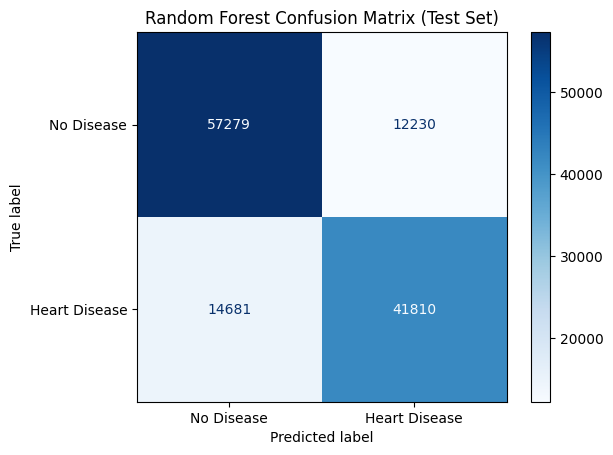


Classification Report (Test Set):
               precision    recall  f1-score   support

   No Disease       0.80      0.82      0.81     69509
Heart Disease       0.77      0.74      0.76     56491

     accuracy                           0.79    126000
    macro avg       0.78      0.78      0.78    126000
 weighted avg       0.79      0.79      0.79    126000



C:\Users\MSI\AppData\Local\Temp\ipykernel_13760\4133920564.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=features_df, palette="viridis")


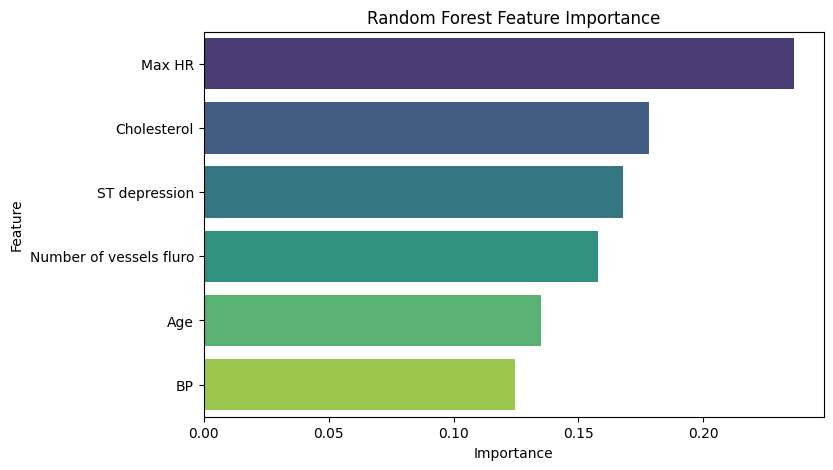

In [13]:
# -----------------------------
# Random Forest Classifier
# -----------------------------
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

# 1️⃣ Define Random Forest classifier
rf_model = RandomForestClassifier(
    n_estimators=200,           # number of trees
    random_state=42,
    class_weight="balanced",    # handle imbalanced classes
    max_depth=None,             # grow trees fully (can tune later)
    n_jobs=-1,
    verbose=1# use all cores
)

# 2️⃣ Train Random Forest
rf_model.fit(X_train, y_train)

# 3️⃣ Predict on test set
y_pred = rf_model.predict(X_test)

# 4️⃣ Evaluate Accuracy
test_acc = accuracy_score(y_test, y_pred)
print(f"Random Forest Test Accuracy: {test_acc:.4f}")

# 5️⃣ Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Disease", "Heart Disease"])
disp.plot(cmap="Blues")
plt.title("Random Forest Confusion Matrix (Test Set)")
plt.show()

# 6️⃣ Classification Report
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_pred, target_names=["No Disease", "Heart Disease"]))

# 7️⃣ Feature Importance
feature_importance = rf_model.feature_importances_
features_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": feature_importance
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x="Importance", y="Feature", data=features_df, palette="viridis")
plt.title("Random Forest Feature Importance")
plt.show()

Fitting 5 folds for each of 40 candidates, totalling 200 fits


c:\Users\MSI\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:200: UserWarning: [15:54:19] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best Parameters: {'subsample': 0.9, 'reg_lambda': 1.5, 'reg_alpha': 0, 'n_estimators': 500, 'max_depth': 4, 'learning_rate': 0.1, 'gamma': 0.1, 'colsample_bytree': 0.8}

✅ Test Accuracy: 0.8869

Classification Report:
               precision    recall  f1-score   support

   No Disease       0.89      0.89      0.89     57709
Heart Disease       0.89      0.88      0.89     56491

     accuracy                           0.89    114200
    macro avg       0.89      0.89      0.89    114200
 weighted avg       0.89      0.89      0.89    114200



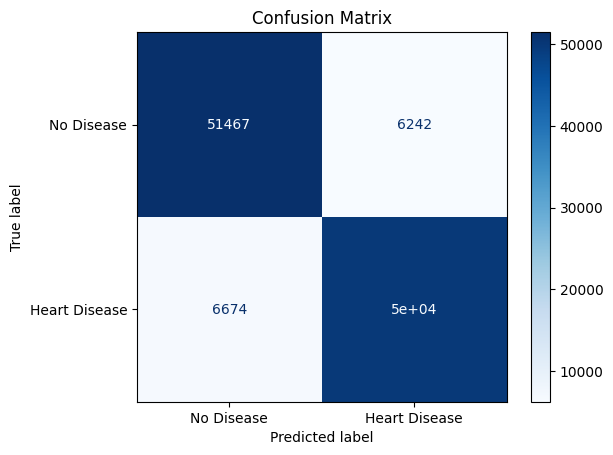


Top Features:
                    Feature  Importance
6                  Thallium    0.340719
32           Chest_Thal_4_7    0.239571
17          Chest pain type    0.088532
18          Exercise angina    0.065046
19              Slope of ST    0.052077
0   Number of vessels fluro    0.049188
30           Chest_Thal_4_3    0.041924
16                      Sex    0.034660
29           Chest_Thal_3_7    0.020939
10                    ST_HR    0.017063
27           Chest_Thal_3_3    0.015473
9                    HR_Age    0.008281
5                    Max HR    0.007408
13                   Low_HR    0.007345
21               Chol_group    0.001423


In [25]:
# =========================================
# IMPORTS
# =========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from xgboost import XGBClassifier

# =========================================
# 1️⃣ FEATURE ENGINEERING
# =========================================

# Original features
numerical_features = ["Number of vessels fluro", "ST depression", "Age", "Cholesterol", "BP", "Max HR", "Thallium"]
categorical_features = ["Sex", "Chest pain type", "Exercise angina", "Slope of ST"]

# ---- Interaction Features ----
df["Age_BP"] = df["Age"] * df["BP"]
df["Chol_Age"] = df["Cholesterol"] * df["Age"]
df["HR_Age"] = df["Max HR"] / (df["Age"] + 1)
df["ST_HR"] = df["ST depression"] / (df["Max HR"] + 1)

# ---- Risk Flags ----
df["High_BP"] = (df["BP"] > 140).astype(int)
df["High_Chol"] = (df["Cholesterol"] > 240).astype(int)
df["Low_HR"] = (df["Max HR"] < 120).astype(int)

# ---- Binning ----
df["Age_group"] = pd.cut(df["Age"], bins=[0,40,55,70,100], labels=False)
df["Chol_group"] = pd.cut(df["Cholesterol"], bins=4, labels=False)

# ---- Log Transform ----
df["Chol_log"] = np.log1p(df["Cholesterol"])
df["BP_log"] = np.log1p(df["BP"])

# ---- Combine categorical features ----
df["Chest_Thal"] = df["Chest pain type"].astype(str) + "_" + df["Thallium"].astype(str)

# =========================================
# 2️⃣ ENCODING
# =========================================

X_cat = pd.get_dummies(
    df[categorical_features + ["Chest_Thal", "Age_group", "Chol_group"]],
    drop_first=True
)

# Combine all features
X = pd.concat([
    df[numerical_features + [
        "Age_BP", "Chol_Age", "HR_Age", "ST_HR",
        "High_BP", "High_Chol", "Low_HR",
        "Chol_log", "BP_log"
    ]],
    X_cat
], axis=1)

y = df["Heart Disease"]

# =========================================
# 3️⃣ TRAIN-TEST SPLIT
# =========================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =========================================
# 4️⃣ XGBOOST + RANDOM SEARCH
# =========================================

xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    use_label_encoder=False
)

param_dist = {
    "n_estimators": [200, 300, 400, 500],
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "gamma": [0, 0.1, 0.2],
    "reg_alpha": [0, 0.01, 0.1],
    "reg_lambda": [1, 1.5, 2]
}

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=40,
    scoring="accuracy",
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Best Parameters:", random_search.best_params_)

best_model = random_search.best_estimator_

# =========================================
# 5️⃣ EVALUATION
# =========================================

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
print(f"\n✅ Test Accuracy: {acc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["No Disease", "Heart Disease"]))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["No Disease", "Heart Disease"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

# =========================================
# 6️⃣ FEATURE IMPORTANCE
# =========================================

importances = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nTop Features:")
print(importances.head(15))

c:\Users\MSI\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:200: UserWarning: [17:39:20] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 225963, number of negative: 230837
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.034135 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 409
[LightGBM] [Info] Number of data points in the train set: 456800, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.494665 -> initscore=-0.021341
[LightGBM] [Info] Start training from score -0.021341

🔥 Ensemble Accuracy: 0.8869

Classification Report:
               precision    recall  f1-score   support

   No Disease       0.89      0.89      0.89     57709
Heart Disease       0.89      0.88      0.89     56491

     accuracy                           0.89    114200
    macro avg       0.89      0.89      0.89    114200
 weighted avg       0.89      

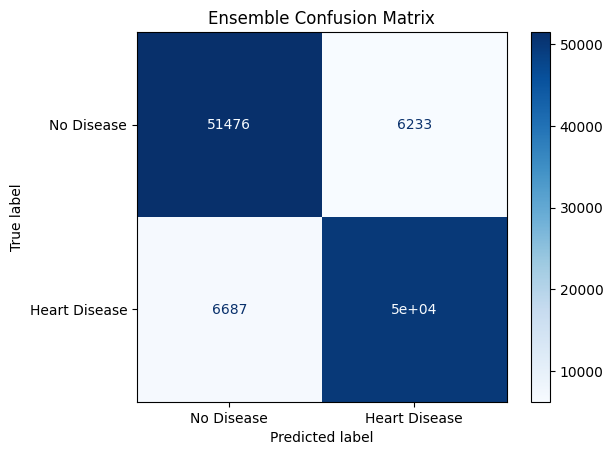

XGB weight 0.8 → Accuracy: 0.8870
XGB weight 0.9 → Accuracy: 0.8870
XGB weight 1.0 → Accuracy: 0.8872
XGB weight 2.0 → Accuracy: 0.8869


In [28]:
# =========================================
# IMPORTS
# =========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# =========================================
# 1️⃣ SAME FEATURE ENGINEERING (KEEP YOUR BEST VERSION)
# =========================================

numerical_features = ["Number of vessels fluro", "ST depression", "Age", "Cholesterol", "BP", "Max HR","Thallium"]
categorical_features = ["Sex", "Chest pain type", "Exercise angina", "Slope of ST"]

X_cat = pd.get_dummies(df[categorical_features], drop_first=True)

X = pd.concat([df[numerical_features], X_cat], axis=1)
y = df["Heart Disease"]

# =========================================
# 2️⃣ SPLIT
# =========================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =========================================
# 3️⃣ MODELS
# =========================================

# ✅ Your BEST XGBoost
xgb_model = XGBClassifier(
    subsample=0.9,
    reg_lambda=1.5,
    reg_alpha=0,
    n_estimators=500,
    max_depth=4,
    learning_rate=0.1,
    gamma=0.1,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss",
    use_label_encoder=False
)

# ✅ LightGBM (strong default tuned slightly)
lgb_model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# Train both
xgb_model.fit(X_train, y_train)
lgb_model.fit(X_train, y_train)

# =========================================
# 4️⃣ ENSEMBLE (SOFT VOTING)
# =========================================

xgb_prob = xgb_model.predict_proba(X_test)[:, 1]
lgb_prob = lgb_model.predict_proba(X_test)[:, 1]

# 🔥 Weighted average (IMPORTANT)
final_prob = (0.6 * xgb_prob) + (0.4 * lgb_prob)

# Convert to class
y_pred = (final_prob >= 0.5).astype(int)

# =========================================
# 5️⃣ EVALUATION
# =========================================

acc = accuracy_score(y_test, y_pred)
print(f"\n🔥 Ensemble Accuracy: {acc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["No Disease", "Heart Disease"]))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["No Disease", "Heart Disease"])
disp.plot(cmap="Blues")
plt.title("Ensemble Confusion Matrix")
plt.show()

# =========================================
# 6️⃣ OPTIONAL: TRY DIFFERENT WEIGHTS
# =========================================

for w in [0.8, 0.9, 1,2]:
    blended = (w * xgb_prob) + ((1 - w) * lgb_prob)
    pred = (blended >= 0.5).astype(int)
    acc = accuracy_score(y_test, pred)
    print(f"XGB weight {w:.1f} → Accuracy: {acc:.4f}")